# **CS 584-A: Natural Language Processing**
# **Homework 1**

**Name: Ankit Dhandharia**

**CWID: 20033031**

## **Goals**
The goal of HW1 is for you to get familiar with extracting features and standard machine learning
workflows, including reading data, preprocessing data, training, testing, and evaluation. All those
are open questions and there is no fixed solution. The difference in data processing, parameter
initialization, data split, etc, will lead to the differences in final predications and evaluation results.
Therefore, during the grading, the specific values in the results are not important. It is important
that you focus on implementing the functions and setting up the pipelines.

## **Task: Sentiment Analysis with Text Classification**
Based on the dataset, the task is to perform sentiment analysis, which predicts the sentiments based
on the free-text reviews. We can simplify the task as a binary classification problem. Specifically, we will
consider the rating 4 and 5 as positive, rating 1 and 2 as negative and for data samples with neutral rating 3, we will discard them.


# **Mounting Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Importing Python Libraries**

In [ ]:
import numpy as np
import pandas as pd
import nltk
import string
from nltk.corpus import stopwords
import re

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

# **Importing Dataset**

The dataset is about the product review dataset from Amazon. The dataset provides product reviews and overall ratings for 4,915 products. We will consider the fine-grained overall ratings as labels, which are ranging from 1 to 5: highly negative, negative, neutral, positive, and highly positive

In [ ]:
dataset = pd.read_csv('drive/MyDrive/amazon_reviews.csv')
dataset

,overall,reviewText
0,4,No issues.
1,5,"Purchased this for my device, it worked as adv..."
2,4,it works as expected. I should have sprung for...
3,5,This think has worked out great.Had a diff. br...
4,5,"Bought it with Retail Packaging, arrived legit..."
...,...,...
4910,1,I bought this Sandisk 16GB Class 10 to use wit...
4911,5,Used this for extending the capabilities of my...
4912,5,Great card that is very fast and reliable. It ...
4913,5,Good amount of space for the stuff I want to d...


# **Tasks 1: Extracting features**

## **1. Data preparation**

### **1.1 Data preprocessing**
(i) converting all text to lowercase to ensure uniformity,

(ii) removing punctuations, numbers, and stopwords, and

(iii) tokenizing the reviews into tokens.

If you plan to work on the binary classification problem, you will need to assign binary class labels based on the above-mentioned strategy

In [ ]:
# Tokenization and stopwords setup
stop_words = set(stopwords.words('english'))

# Initialize an empty list to store cleaned texts
cleaned_texts = []

# Loop through the dataset to clean and tokenize each text
for text in dataset["reviewText"]:
    # Convert text to lowercase and remove punctuations/numbers
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    text = re.sub(r'\d', '', text)

    # Tokenize the cleaned text
    words = nltk.word_tokenize(text)

    # Filter out stopwords
    tokenized_text = [word for word in words if word not in stop_words]

    # Append cleaned and tokenized text to the list
    cleaned_texts.append(tokenized_text)

# Assign the cleaned texts back to the dataframe
dataset["reviewText"] = cleaned_texts

dataset

,overall,reviewText
0,4,[issues]
1,5,"[purchased, device, worked, advertised, never,..."
2,4,"[works, expected, sprung, higher, capacity, th..."
3,5,"[think, worked, greathad, diff, bran, gb, card..."
4,5,"[bought, retail, packaging, arrived, legit, or..."
...,...,...
4910,1,"[bought, sandisk, gb, class, use, htc, inspire..."
4911,5,"[used, extending, capabilities, samsung, galax..."
4912,5,"[great, card, fast, reliable, comes, optional,..."
4913,5,"[good, amount, space, stuff, want, fits, gopro..."


### **1.2 Data split**
Split the data with the ratio of 0.8, 0.1, and 0.1 into training, validation/development, and testing, respectively

In [ ]:
from sklearn.model_selection import train_test_split

train, temp = train_test_split(dataset, test_size=0.2, random_state=100) #Spliting dataset into training (80%) and remaining (20%)

val, test = train_test_split(temp, test_size=0.5, random_state=100) #Spliting the remaining 20% into validation (10%) and test (10%)

#Checking the shape of the splits to verify the ratios
print(f'Training set: {train.shape}')
print(f'Validation set: {val.shape}')
print(f'Test set: {test.shape}')

Training set: (3932, 2)
Validation set: (491, 2)
Test set: (492, 2)


### **1.3 Data statistics**
Number of data samples in training/development/testing, minimum/average maximum number of tokens across all reviews, number of positive/negative reviews in training/development/testing

In [ ]:
def get_num_tokens(review_text):
    return len(str(review_text).split())

dataset_stat = {
    'Group of data': ['Training Data',
                      'Validation Data',
                      'Testing Data'],
    'Samples Data': [len(train),
                      len(val),
                      len(test)],
    'Min Token': [min(train['reviewText'].apply(get_num_tokens)),
                     min(val['reviewText'].apply(get_num_tokens)),
                     min(test['reviewText'].apply(get_num_tokens))],
    'Min Positive Reviews Tokens': [min(train['reviewText'][train['overall'] > 3].apply(get_num_tokens)),
                                         min(val['reviewText'][val['overall'] > 3].apply(get_num_tokens)),
                                         min(test['reviewText'][test['overall'] > 3].apply(get_num_tokens))],
    'Min Negative Reviews Tokens': [min(train['reviewText'][train['overall'] < 3].apply(get_num_tokens)),
                                         min(val['reviewText'][val['overall'] < 3].apply(get_num_tokens)),
                                         min(test['reviewText'][test['overall'] < 3].apply(get_num_tokens))],
    'Avg Tokens': [train['reviewText'].apply(get_num_tokens).mean(),
                     val['reviewText'].apply(get_num_tokens).mean(),
                     test['reviewText'].apply(get_num_tokens).mean()],
    'Avg Positive Reviews Tokens': [train['reviewText'][train['overall'] > 3].apply(get_num_tokens).mean(),
                                         val['reviewText'][val['overall'] > 3].apply(get_num_tokens).mean(),
                                         test['reviewText'][test['overall'] > 3].apply(get_num_tokens).mean()],
    'Avg Negative Reviews Tokens': [train['reviewText'][train['overall'] < 3].apply(get_num_tokens).mean(),
                                         val['reviewText'][val['overall'] < 3].apply(get_num_tokens).mean(),
                                         test['reviewText'][test['overall'] < 3].apply(get_num_tokens).mean()],
    'Max Tokens': [max(train['reviewText'].apply(get_num_tokens)),
                     max(val['reviewText'].apply(get_num_tokens)),
                     max(test['reviewText'].apply(get_num_tokens))],
    'Max Positive Reviews Tokens': [max(train['reviewText'][train['overall'] > 3].apply(get_num_tokens)),
                                         max(val['reviewText'][val['overall'] > 3].apply(get_num_tokens)),
                                         max(test['reviewText'][test['overall'] > 3].apply(get_num_tokens))],
    'Max Negative Reviews Tokens': [max(train['reviewText'][train['overall'] < 3].apply(get_num_tokens)),
                                         max(val['reviewText'][val['overall'] < 3].apply(get_num_tokens)),
                                         max(test['reviewText'][test['overall'] < 3].apply(get_num_tokens))],
    'Positive Reviews': [len(train[train['overall'] > 3]),
                           len(val[val['overall'] > 3]),
                           len(test[test['overall'] > 3])],
    'Negative Reviews': [len(train[train['overall'] < 3]),
                          len(val[val['overall'] < 3]),
                          len(test[test['overall'] < 3])]
}

Stat_table = pd.DataFrame(dataset_stat)

Stat_table

,Group of data,Samples Data,Min Token,Min Positive Reviews Tokens,Min Negative Reviews Tokens,Avg Tokens,Avg Positive Reviews Tokens,Avg Negative Reviews Tokens,Max Tokens,Max Positive Reviews Tokens,Max Negative Reviews Tokens,Positive Reviews,Negative Reviews
0,Training Data,3932,1,1,2,25.332655,22.894722,54.957692,781,544,781,3562,260
1,Validation Data,491,1,1,12,24.898167,22.493213,54.031250,240,240,147,442,32
2,Testing Data,492,1,1,8,26.178862,24.480899,36.656250,364,364,78,445,32


## **2. Representation of Texts**

## **1. Count-based word vectors with co-occurrence matrix**

**1.a** Implement a function named get_vacab(corpus) that returns corpus_words, which is the list of all the distinct words used in the review corpus. You can do this with ‘for’ loops, but it's more efficient to do it with Python list comprehensions. The returned corpus_words should be sorted.

In [ ]:
def get_vacab(corpus):

    distinct_words = []

    for i in range(len(corpus)):
        for word in corpus[i]:
            if word not in distinct_words: #Checking if the word existing in the list.
                distinct_words.append(word)

    corpus_words = sorted(distinct_words) #Sorting the list

    return corpus_words

corpus_words = get_vacab(dataset['reviewText'])
corpus_words

['aac',
 'aas',
 'aba',
 'abdroid',
 'abilities',
 'ability',
 'able',
 'aboutgood',
 'abouti',
 'abouttherehere',
 'aboutto',
 'abovei',
 'abroad',
 'abruptly',
 'absolute',
 'absolutely',
 'abt',
 'abuse',
 'abused',
 'abysmal',
 'accdientally',
 'accept',
 'acceptable',
 'acceptably',
 'accepted',
 'accepting',
 'accepts',
 'access',
 'accessed',
 'accesses',
 'accessible',
 'accessing',
 'accessories',
 'accessory',
 'accessoryalternative',
 'accident',
 'accidentally',
 'accidently',
 'acclimated',
 'accolades',
 'accommodate',
 'accomplish',
 'accord',
 'according',
 'accordingly',
 'account',
 'accros',
 'accurate',
 'accuratei',
 'accuratethe',
 'ace',
 'acer',
 'acess',
 'acheive',
 'achieve',
 'achieved',
 'achievedusing',
 'achieves',
 'acitve',
 'acknowledge',
 'acknowledged',
 'acontourroam',
 'acquire',
 'acquired',
 'acronis',
 'acronyms',
 'across',
 'act',
 'acting',
 'action',
 'actioncam',
 'activating',
 'active',
 'activity',
 'acts',
 'actual',
 'actuality',
 'act

**1.b** Based on the word vocabulary obtained with get_vacab(corpus) function, please implement a function named compute_co_occurrence_matrix(corpus, window_size=4) that returns both M and word2index. Here, M is the co-occurrence matrix of word counts and word2index is a dictionary that maps word to index. The function constructs a co-occurrence matrix for a certain window-size $n$ (with a default of 4), considering words $n$ before and $n$ after the word in the center of the window. You can use numpy to represent vectors, matrices, and tensors

In [ ]:
def compute_co_occurrence_matrix(corpus, corpus_words, window_size=4):
    M = np.zeros((len(corpus_words), len(corpus_words)), dtype=np.int32) #Initializing matrix M with zeros

    word2index = {word: index for index, word in enumerate(corpus_words)} #Creating a hashmap to map the relationship between word and index

    for words_list in corpus: #Iterating through list of strings in the corpus
        for index, word in enumerate(words_list): #Iterating through word in the list of words
            center_word_index = word2index.get(word, -1)

            if center_word_index != -1: #Checking if the word is in the vocabulary
                start = max(0, index - window_size)
                end = min(len(words_list), index + window_size + 1)

                for index_in_window in range(start, end): #Iterating through the words in the window
                    if index_in_window == index: #Skiping the center word itself
                        continue

                    word_in_window = words_list[index_in_window] #Getting the word of the current index in the window

                    word_in_window_index = word2index.get(word_in_window, -1) #Getting the index of the current word in the window

                    if word_in_window_index != -1: #If the word is found in the vocabulary matrix is updated
                        M[center_word_index][word_in_window_index] += 1

    return M, word2index

M_count_based, word2index_count_based = compute_co_occurrence_matrix(dataset['reviewText'], corpus_words)
M_count_based.shape

(9697, 9697)

In [ ]:
word2index_count_based

{'aac': 0,
 'aas': 1,
 'aba': 2,
 'abdroid': 3,
 'abilities': 4,
 'ability': 5,
 'able': 6,
 'aboutgood': 7,
 'abouti': 8,
 'abouttherehere': 9,
 'aboutto': 10,
 'abovei': 11,
 'abroad': 12,
 'abruptly': 13,
 'absolute': 14,
 'absolutely': 15,
 'abt': 16,
 'abuse': 17,
 'abused': 18,
 'abysmal': 19,
 'accdientally': 20,
 'accept': 21,
 'acceptable': 22,
 'acceptably': 23,
 'accepted': 24,
 'accepting': 25,
 'accepts': 26,
 'access': 27,
 'accessed': 28,
 'accesses': 29,
 'accessible': 30,
 'accessing': 31,
 'accessories': 32,
 'accessory': 33,
 'accessoryalternative': 34,
 'accident': 35,
 'accidentally': 36,
 'accidently': 37,
 'acclimated': 38,
 'accolades': 39,
 'accommodate': 40,
 'accomplish': 41,
 'accord': 42,
 'according': 43,
 'accordingly': 44,
 'account': 45,
 'accros': 46,
 'accurate': 47,
 'accuratei': 48,
 'accuratethe': 49,
 'ace': 50,
 'acer': 51,
 'acess': 52,
 'acheive': 53,
 'achieve': 54,
 'achieved': 55,
 'achievedusing': 56,
 'achieves': 57,
 'acitve': 58,
 'ackno

**1.c** Implement a function named reduce_to_k_dim(M) performs dimensionality
reduction on the matrix M to produce k-dimensional embeddings and returns the new matrix M_reduced. Use SVD (use the implementation of Truncated SVD in sklearn sklearn.decomposition.TruncatedSVD, set n_iters = 10) to take the top k components and produce a new matrix of k-dimensional embeddings.

In [ ]:
from sklearn.decomposition import TruncatedSVD

def reduce_to_k_dim(M, k=2):
    svd = TruncatedSVD(n_components=k, n_iter=10, random_state=100) #Creating a TruncatedSVD model with k components and 10 iterations

    M_reduced = svd.fit_transform(M) #Fit the model to matrix M and transform it to get the reduced matrix

    return M_reduced

M_reduced_count_based = reduce_to_k_dim(M_count_based, k=2)

M_reduced_count_based.shape

(9697, 2)

In [ ]:
M_reduced_count_based

array([[ 0.12846658, -0.10059098],
       [ 0.18762799, -0.03384236],
       [ 1.64781196,  1.15541128],
       ...,
       [ 1.07253206,  0.60830461],
       [ 1.27791587,  0.22853538],
       [ 0.09724572, -0.02260818]])

**1.d** Implement plot_embeddings(M_reduced, word2index, words_to_plot) to plot in a
scatterplot the embeddings of the words specified in the list ‘words_to_plot’. Here, ‘M_reduced’ is the matrix of 2-dimensional word embeddings obtained in question c. word2index is the dictionary that maps words to indices for the embedding matrix obtained in question b.
Use the implemented function to get the plot for the following list of words
words_to_plot=[‘purchase’, ‘buy’, ‘work’, ‘got’, ‘ordered’, ‘received’, ‘product’, ‘item’, ‘deal’, ‘use’], and show the plot.

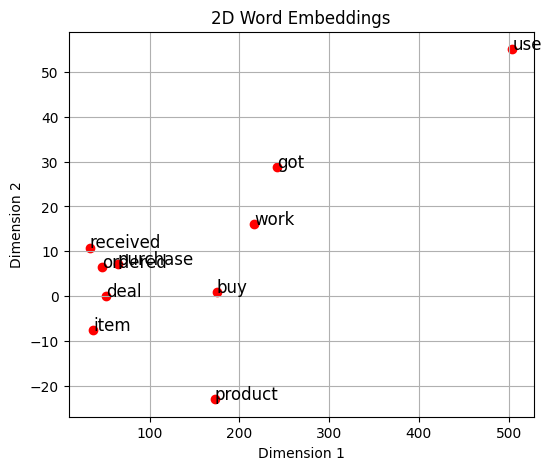

In [ ]:
import matplotlib.pyplot as plt

def plot_embeddings(M_reduced, word2index, words_to_plot):

    plt.figure(figsize=(6, 5))

    for word in words_to_plot:
        index = word2index.get(word, None) #Getting the index of the word from the word2index dictionary
        if index is not None: #Plotting the word embedding as a scatter point
            x, y = M_reduced[index]
            plt.scatter(x, y, marker='o', color='red')
            plt.text(x + 0.01, y + 0.01, word, fontsize=12)  # Label the word on the plot

    plt.title('2D Word Embeddings')
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
    plt.grid(True)
    plt.show()

words_to_plot = ['purchase', 'buy', 'work', 'got', 'ordered', 'received', 'product', 'item', 'deal', 'use']  #List of words to plot

plot_embeddings(M_reduced_count_based, word2index_count_based, words_to_plot)

## **2. Prediction-based word vectors from Glove**

**2.a** Please use the provided load_embedding_model() function to load the GloVe
embeddings. Note: If this is your first time to run these cells, i.e. download the embedding model, it will take a couple minutes to run. If you've run these cells before, rerunning them will load the model without redownloading it, which will take about 1 to 2 minutes

In [ ]:
import gensim.downloader as api

def load_embedding_model():
    """
    Load GloVe Vectors.

    Return:
    wv_from_bin: All 400000 embeddings, each of length 200
    """
    wv_from_bin = api.load("glove-wiki-gigaword-200")
    print("Loaded vocab size %i" % len(list(wv_from_bin.index_to_key)))
    return wv_from_bin

# Run the function to load GloVe word vectors
wv_from_bin = load_embedding_model()

[==================================================] 100.0% 252.1/252.1MB downloaded
Loaded vocab size 400000


**2.b** Select the words in the vocabulary returned in 1)a and get the corresponding GloVe vectors. You can adapt the provided function get_matrix_of_vectors(wv_from_bin, required_words) to select the Glove vectors and put them in a matrix M.

In [ ]:
def get_matrix_of_vectors(wv_from_bin, required_words):

    """ Put the GloVe vectors into a matrix M.
        Param:
            wv_from_bin: KeyedVectors object; the 400000 GloVe vectors loaded from file
            required_words: the list of strings that contains all required words
        Return:
            M: numpy matrix shape (num words, 200) containing the vectors
            word2ind: dictionary mapping each word to its row number in M
    """

    import random
    words = list(wv_from_bin.index_to_key)
    print("Shuffling words ...")
    random.seed(225)
    random.shuffle(words)
    words = words[:]
    print("Putting %i words into word2index and matrix M..." % len(required_words))
    word2index = {}
    M = []
    curIndex = 0
    default_vector = np.zeros(200)

    for word in required_words:
        if word in words:
            M.append(wv_from_bin.get_vector(word))
            word2index[word] = curIndex
            curIndex += 1
        else:
            M.append(default_vector)
            word2index[word] = curIndex
            curIndex += 1
    M = np.stack(M)
    print("Done.")
    return M, word2index

M_pred_based, word2index_pred_based = get_matrix_of_vectors(wv_from_bin, corpus_words)
M_pred_based

Shuffling words ...
Putting 9697 words into word2index and matrix M...
Done.


array([[ 0.22586   ,  0.055649  ,  0.28367999, ..., -0.28356999,
         0.36353001, -0.87370002],
       [ 0.23273   , -0.048693  ,  0.76813   , ..., -0.55684   ,
        -0.44095999,  0.20299999],
       [-0.075412  ,  0.34158   , -0.66105002, ...,  0.14579   ,
        -0.57616001, -0.022035  ],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [-0.35547999,  0.22649001, -0.37088999, ..., -0.062321  ,
         0.19923   , -0.15657   ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ]])

**2.c** Use the function reduce_to_k_dim() you implemented in 1)c to reduce the vectors to 2 dimension. Similar to what you did in 1)c